In [1]:
# Import required modules
import os
import numpy as np
import tensorflow as tf
import tensorflow_hub as hub
import requests
from pycocotools.coco import COCO
from PIL import Image
import matplotlib.pyplot as plt
from io import BytesIO

In [2]:
import os

# Define the directory paths
annotation_dir = '/content/annotations'
image_dir = '/content/images'

# Create the directories if they do not exist
os.makedirs(annotation_dir, exist_ok=True)
os.makedirs(image_dir, exist_ok=True)


In [3]:
!wget -q -P /content/annotations http://images.cocodataset.org/annotations/annotations_trainval2017.zip
!unzip -q /content/annotations/annotations_trainval2017.zip -d /content/annotations


In [4]:
import os

# Define the path to the annotations file
annotations_file = '/content/annotations/annotations/instances_val2017.json'

# Check if the file exists
if os.path.exists(annotations_file):
    print(f"Annotations file found at: {annotations_file}")
else:
    print(f"Annotations file not found at: {annotations_file}")


Annotations file found at: /content/annotations/annotations/instances_val2017.json


In [5]:
ANNOTATION_FILE = '/content/annotations/annotations/instances_val2017.json'

loading annotations into memory...
Done (t=0.83s)
creating index...
index created!


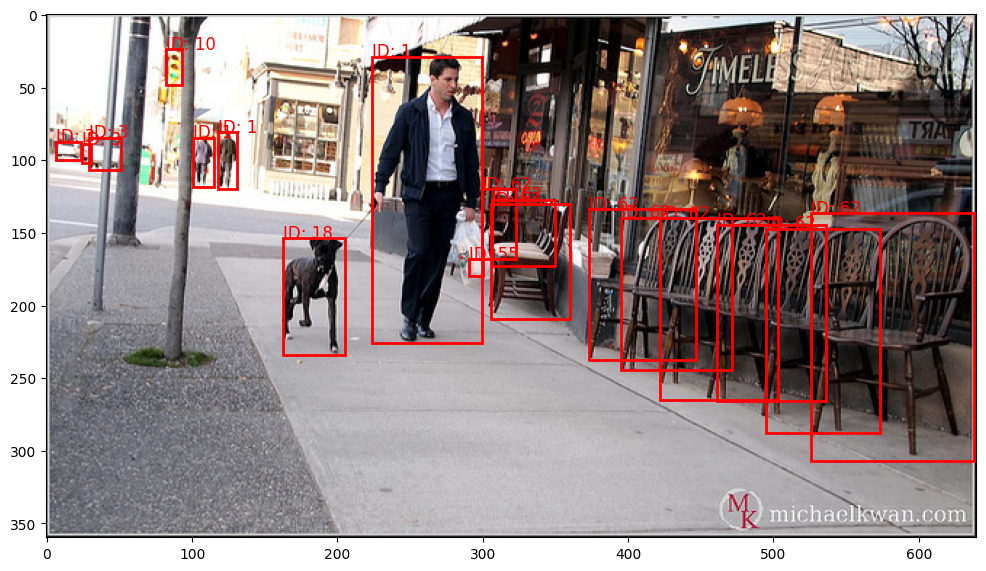

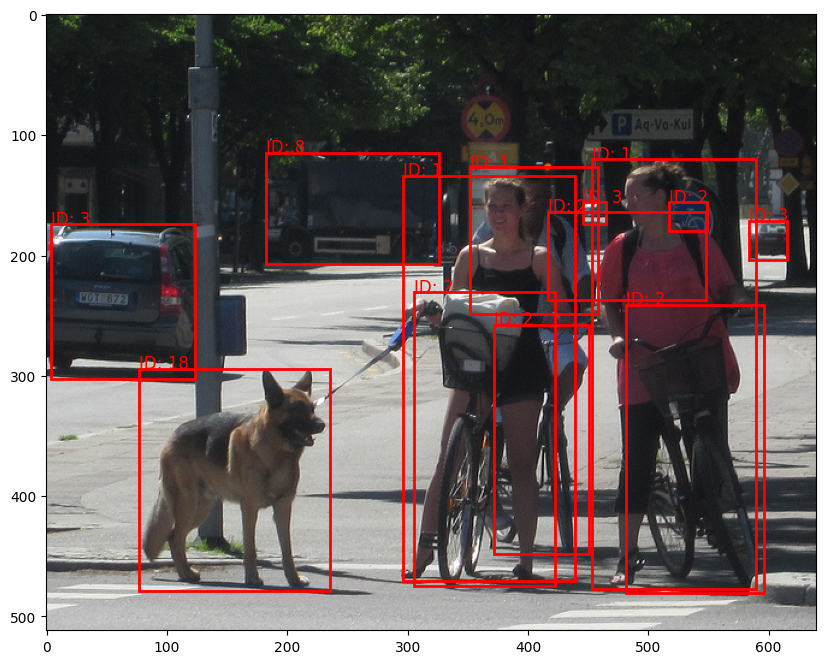

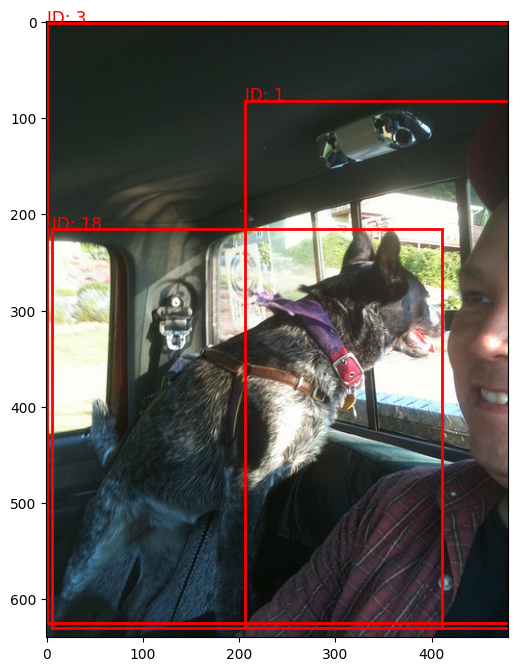

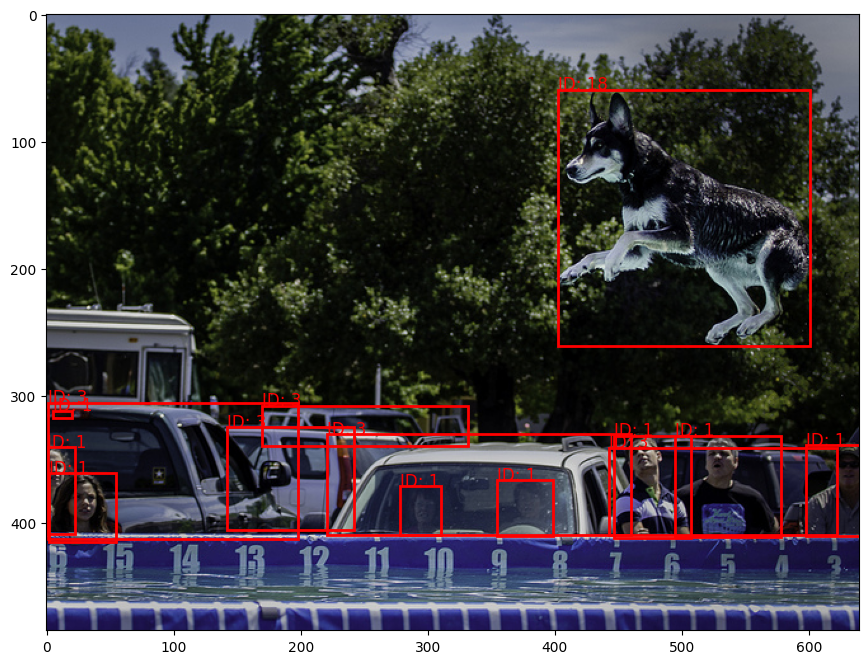

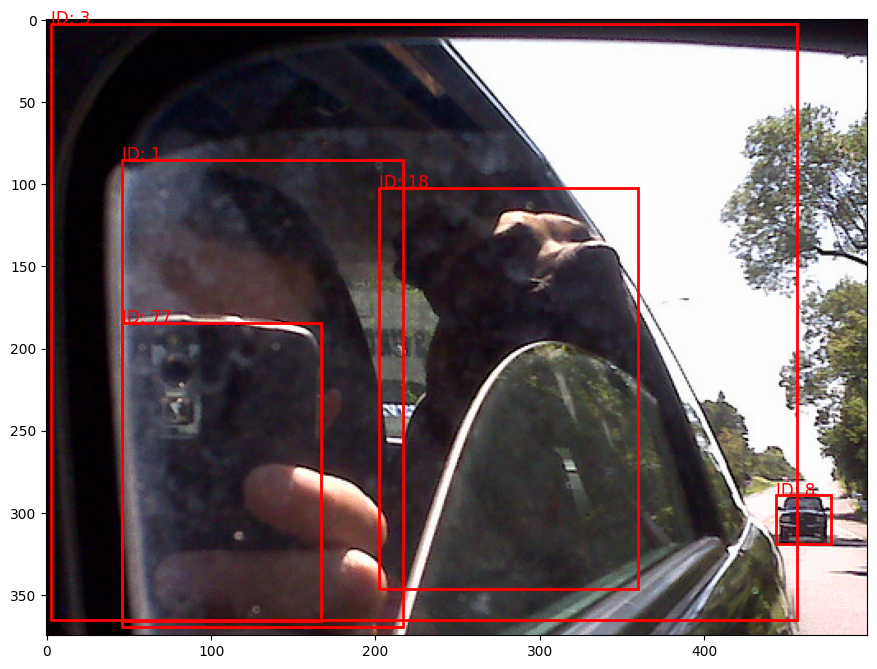

In [6]:

# Initialize COCO API for image annotations
coco = COCO(ANNOTATION_FILE)

# Define categories of interest (e.g., 'person', 'car', 'dog')
categories_of_interest = ['person', 'car', 'dog']
cat_ids = coco.getCatIds(catNms=categories_of_interest)
img_ids = coco.getImgIds(catIds=cat_ids)

# Select a subset of images (e.g., first 5 images)
subset_img_ids = img_ids[:5]
images = coco.loadImgs(subset_img_ids)

# Function to download and preprocess images
def load_image(image_info):
    image_url = image_info['coco_url']
    response = requests.get(image_url)
    image = Image.open(BytesIO(response.content))
    image = image.convert('RGB')
    return np.array(image)

# Function to display image with annotations
def display_image_with_annotations(image, image_info, annotations):
    plt.figure(figsize=(12, 8))
    plt.imshow(image)
    ax = plt.gca()
    for ann in annotations:
        bbox = ann['bbox']
        rect = plt.Rectangle((bbox[0], bbox[1]), bbox[2], bbox[3], linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(rect)
        plt.text(bbox[0], bbox[1], f"ID: {ann['category_id']}", color='red', fontsize=12)
    plt.show()

# Load and display images with annotations
for image_info in images:
    image = load_image(image_info)
    ann_ids = coco.getAnnIds(imgIds=image_info['id'])
    anns = coco.loadAnns(ann_ids)
    display_image_with_annotations(image, image_info, anns)



IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

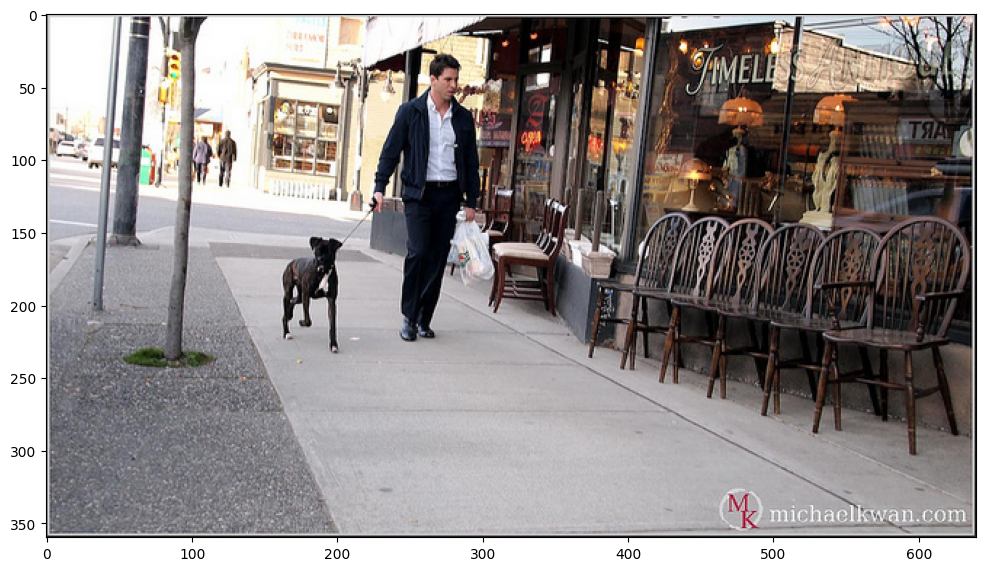

In [7]:
# Load a pre-trained object detection model from TensorFlow Hub
model_url = "https://tfhub.dev/tensorflow/faster_rcnn/resnet50_v1_640x640/1"
model = hub.load(model_url)

# Function to run inference
def run_inference(model, image_np):
    image_tensor = tf.convert_to_tensor(image_np)
    image_tensor = image_tensor[tf.newaxis,...]
    output_dict = model(image_tensor)
    num_detections = int(output_dict.pop('num_detections'))
    output_dict = {key:value[0, :num_detections].numpy() for key,value in output_dict.items()}
    output_dict['num_detections'] = num_detections
    return output_dict


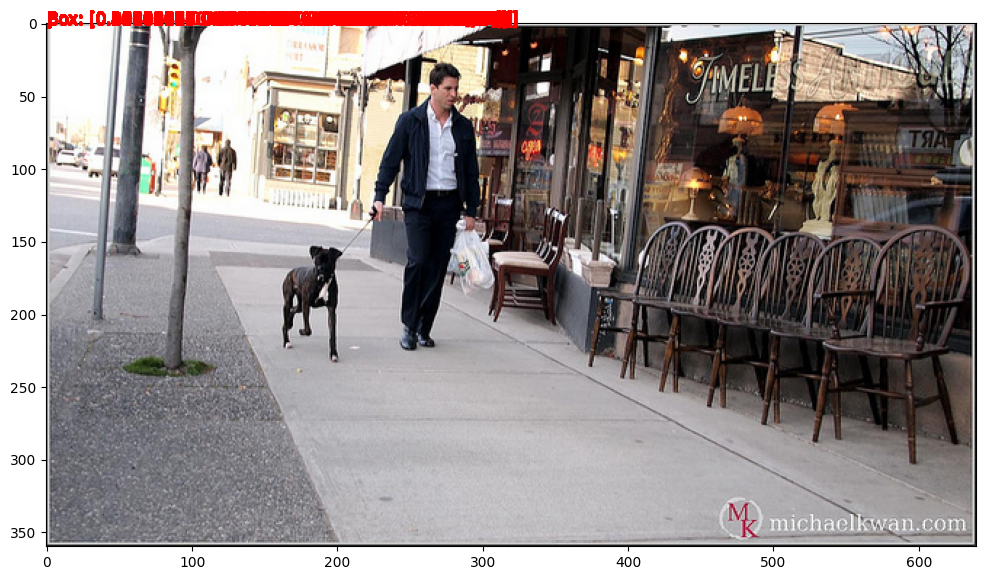

{'raw_detection_boxes': array([[0.07343262, 0.34461206, 0.6349572 , 0.46348482],
       [0.4108308 , 0.24415724, 0.62950075, 0.31979865],
       [0.3864257 , 0.8273978 , 0.8323229 , 0.9881341 ],
       ...,
       [0.6010411 , 0.8296688 , 0.7921694 , 0.944252  ],
       [0.24510507, 0.1070187 , 0.32920316, 0.12089163],
       [0.2688127 , 0.7111689 , 0.35906196, 0.7315958 ]], dtype=float32), 'detection_multiclass_scores': array([[1.6100960e-03, 9.9817711e-01, 3.1152258e-06, ..., 3.7941318e-06,
        9.5871144e-07, 1.0125895e-06],
       [9.0265619e-03, 1.2257288e-04, 1.5087962e-05, ..., 3.7687559e-07,
        2.3558714e-07, 1.3860289e-07],
       [7.3876767e-03, 6.0614253e-05, 1.5214264e-05, ..., 7.9670218e-07,
        2.5943659e-06, 6.6588171e-07],
       ...,
       [5.5935258e-01, 3.2342666e-01, 3.7728548e-03, ..., 2.2246346e-03,
        4.7065474e-05, 1.7419343e-05],
       [7.1810007e-01, 5.2010883e-03, 9.1232290e-04, ..., 3.2497672e-05,
        6.2568659e-05, 2.0890578e-04],
  

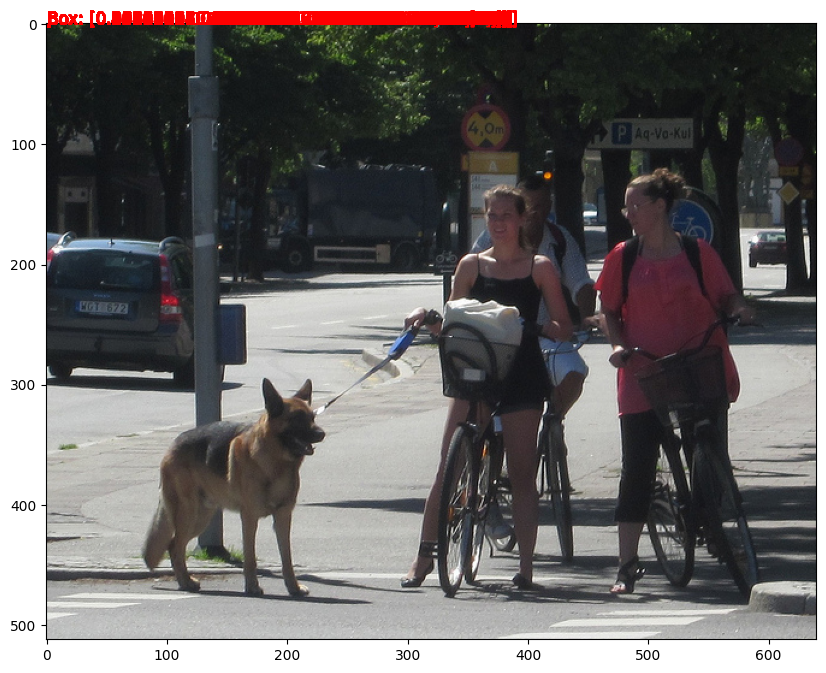

{'raw_detection_boxes': array([[2.4550959e-01, 7.1121460e-01, 9.3438721e-01, 9.2076808e-01],
       [3.3768648e-01, 7.7521801e-04, 5.8146000e-01, 2.0861204e-01],
       [2.5965118e-01, 5.1444173e-01, 8.8738060e-01, 7.1291846e-01],
       ...,
       [3.5145545e-01, 5.3357172e-01, 3.9286876e-01, 5.7236207e-01],
       [4.8639053e-01, 4.3546414e-01, 5.5179006e-01, 4.9173209e-01],
       [3.4122229e-01, 1.4880787e-01, 3.9435959e-01, 1.9367354e-01]],
      dtype=float32), 'detection_multiclass_scores': array([[2.5111425e-03, 9.9648160e-01, 1.6340884e-04, ..., 4.3430548e-05,
        2.9440139e-06, 2.2780405e-06],
       [7.4443460e-04, 2.4757719e-05, 2.0642856e-06, ..., 3.2806236e-06,
        1.6436643e-07, 9.7324744e-08],
       [3.4228878e-03, 2.1680353e-05, 2.0558175e-06, ..., 2.7095376e-07,
        1.3289282e-07, 3.5707021e-08],
       ...,
       [9.4935632e-01, 2.5593037e-02, 1.3555225e-04, ..., 4.4107248e-05,
        8.9987407e-06, 8.8071092e-06],
       [9.9564874e-01, 1.2531832e-03

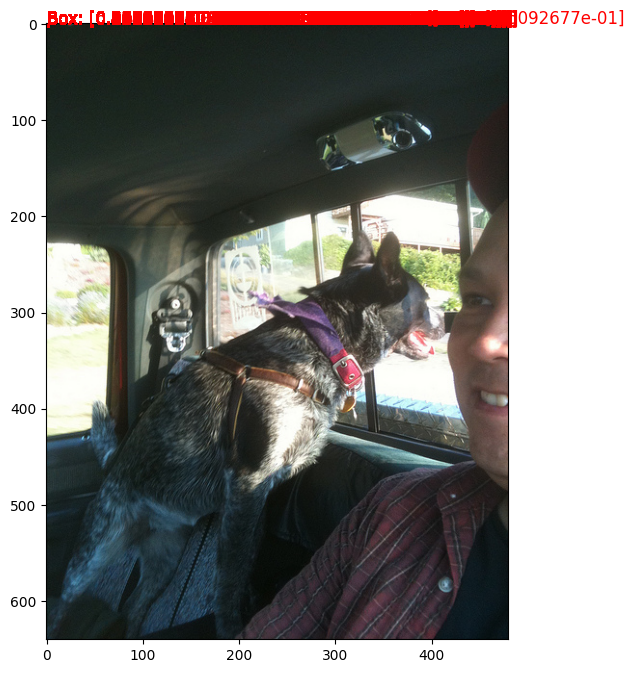

{'raw_detection_boxes': array([[0.33668706, 0.0577035 , 0.9839392 , 0.8981227 ],
       [0.36648345, 0.04374619, 0.98091793, 0.87179685],
       [0.2904882 , 0.06058906, 0.9747128 , 0.86567414],
       ...,
       [0.48965168, 0.0158714 , 0.991834  , 0.7191789 ],
       [0.27051985, 0.2794274 , 0.7088901 , 0.8051566 ],
       [0.45086527, 0.8458419 , 0.51986617, 0.896657  ]], dtype=float32), 'detection_multiclass_scores': array([[7.54812686e-03, 2.91996845e-03, 1.14269005e-05, ...,
        3.38138052e-05, 7.50705908e-07, 1.89601565e-07],
       [5.76953515e-02, 9.36354518e-01, 2.57689098e-05, ...,
        4.24522550e-05, 6.15824729e-06, 4.09612767e-06],
       [1.60740957e-01, 2.06792471e-03, 6.28497946e-05, ...,
        1.12075111e-04, 7.60666398e-06, 3.42937051e-06],
       ...,
       [6.03601992e-01, 1.54718505e-02, 1.33390058e-04, ...,
        2.92499084e-04, 1.00260786e-05, 6.66943288e-06],
       [9.21367526e-01, 1.29252730e-03, 1.09286141e-03, ...,
        1.09195398e-05, 1.798

KeyboardInterrupt: 

In [10]:
# Evaluate the model on the subset of images
for image_info in images:
    image = load_image(image_info)
    output_dict = run_inference(model, image)
    # Display the image with detections
    display_image_with_annotations(image, image_info, output_dict['detection_boxes'])
    # Here, you can implement code to calculate accuracy metrics such as IoU, precision, recall, etc.
    # For simplicity, we're just displaying the output_dict.
    print(output_dict)

In [ ]:
# Check current versions
import tensorflow as tf
import tensorflow_hub as hub

print(f"TensorFlow version: {tf.__version__}")
print(f"TensorFlow Hub version: {hub.__version__}")

# Upgrade to the latest versions if needed
!pip install --upgrade tensorflow tensorflow-hub


In [ ]:
import tensorflow_hub as hub

# Load the model without specifying a signature
model_url = "https://tfhub.dev/tensorflow/faster_rcnn/resnet50_v1_640x640/1"
model = hub.load(model_url)

# Check available signatures
print(model.signatures.keys())


In [ ]:
# Install the TensorFlow Object Detection API
!pip install tf-slim
!pip install tensorflow-object-detection-api


In [ ]:
import tensorflow as tf
from object_detection.utils import model_util
from object_detection.utils import visualization_utils as vis_util
from object_detection.utils import label_map_util

# Load the pre-trained Faster R-CNN model
PATH_TO_FROZEN_GRAPH = 'path_to_frozen_inference_graph.pb'
detection_graph = tf.Graph()
with detection_graph.as_default():
    od_graph_def = tf.GraphDef()
    with tf.gfile.GFile(PATH_TO_FROZEN_GRAPH, 'rb') as fid:
        serialized_graph = fid.read()
        od_graph_def.ParseFromString(serialized_graph)
        tf.import_graph_def(od_graph_def, name='')

# Load label map
PATH_TO_LABELS = 'path_to_label_map.pbtxt'
label_map = label_map_util.load_labelmap(PATH_TO_LABELS)
categories = label_map_util.convert_label_map_to_categories(label_map, max_num_classes=90, use_display_name=True)
category_index = label_map_util.create_category_index(categories)


In [ ]:
with detection_graph.as_default():
    with tf.Session(graph=detection_graph) as sess:
        # Define input and output tensors
        image_tensor = detection_graph.get_tensor_by_name('image_tensor:0')
        detection_boxes = detection_graph.get_tensor_by_name('detection_boxes:0')
        detection_scores = detection_graph.get_tensor_by_name('detection_scores:0')
        detection_classes = detection_graph.get_tensor_by_name('detection_classes:0')
        num_detections = detection_graph.get_tensor_by_name('num_detections:0')

        # Run inference on your image
        # (Assuming 'image_np' is your input image as a numpy array)
        image_np_expanded = np.expand_dims(image_np, axis=0)
        (boxes, scores, classes, num) = sess.run(
            [detection_boxes, detection_scores, detection_classes, num_detections],
            feed_dict={image_tensor: image_np_expanded}
        )

        # Visualization of the results
        vis_util.visualize_boxes_and_labels_on_image_array(
            image_np,
            np.squeeze(boxes),
            np.squeeze(classes).astype(np.int32),
            np.squeeze(scores),
            category_index,
            instance_masks=np.squeeze(masks) if 'masks' in locals() else None,
            use_normalized_coordinates=True,
            line_thickness=8
        )
